# Quantum Key Distribution: The BB84 Protocol

Every cipher so far in this module has bet its security on **computation**. RSA is safe only as long as factoring stays hard - and the previous lesson showed Shor's algorithm dismantling exactly that assumption. So here is the question that closes the course: if a quantum computer can break the math, what is left to protect a secret?

BB84 (Bennett and Brassard, 1984) answers with **physics**. Alice sends Bob a key one photon at a time, each bit encoded in a photon's **polarization**. The security does not rest on any problem being hard. It rests on a law: you cannot measure an unknown quantum state without disturbing it, and you cannot copy it at all (the **no-cloning theorem**). An eavesdropper who tries to read the photons inevitably scrambles them - and Alice and Bob can simply check for the damage.

This notebook builds the protocol, plays the eavesdropper, and watches the physics refuse to be hacked.


## 1. Two Bases for One Bit

Alice encodes each bit by choosing one of two **bases**:

- the **rectilinear** basis `+`: bit 0 is horizontal polarization, bit 1 is vertical.
- the **diagonal** basis `x`: bit 0 is 45 degrees, bit 1 is 135 degrees.

The catch that makes everything work: if you measure a photon in the **same** basis Alice used, you read its bit perfectly. If you measure in the **wrong** basis, you get a completely **random** result - and you destroy the original polarization in the process. There is no measurement that reads both bases at once.


**Imports and setup.** Arrays, plotting, animation, and the two bases.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

RECT, DIAG = 0, 1
BASIS = {RECT: "+", DIAG: "x"}

rng = np.random.default_rng(7)


## 2. The Protocol With No Eavesdropper

One run of BB84:

1. **Alice** picks a random bit and a random basis for each photon, encodes, and sends.
2. **Bob** picks a random basis for each photon and measures.
3. **Sift.** Over a public channel they compare *only which bases they used* (never the bits). They keep the bits where their bases matched and discard the rest.

When their bases match and nobody interfered, Bob's measurement equals Alice's bit exactly. Bases match about half the time, so a run of `n` photons yields roughly `n/2` shared key bits.


**Simulate a run.** Vectorized over `n` photons; an optional eavesdropper is added later.


In [2]:
def simulate(n, rng, eve_fraction=0.0, classical=False):
    a_bits = rng.integers(2, size=n)
    a_bases = rng.integers(2, size=n)
    b_bases = rng.integers(2, size=n)

    # The state travelling down the channel (Eve may overwrite some photons).
    state_bits = a_bits.copy()
    state_bases = a_bases.copy()
    intercepted = rng.random(n) < eve_fraction

    if classical:
        # No-cloning is broken: Eve copies the bit perfectly, no disturbance.
        eve_known = intercepted.copy()
    else:
        e_bases = rng.integers(2, size=n)
        e_meas = np.where(e_bases == a_bases, a_bits, rng.integers(2, size=n))
        state_bits = np.where(intercepted, e_meas, state_bits)   # Eve resends what she saw
        state_bases = np.where(intercepted, e_bases, state_bases)
        eve_known = intercepted & (e_bases == a_bases)           # Eve is certain only on a basis match

    b_bits = np.where(b_bases == state_bases, state_bits, rng.integers(2, size=n))
    sift = a_bases == b_bases
    return {"a_bits": a_bits, "a_bases": a_bases, "b_bases": b_bases, "b_bits": b_bits,
            "sift": sift, "intercepted": intercepted, "eve_known": eve_known}


def qber(run):
    s = run["sift"]
    return float((run["a_bits"][s] != run["b_bits"][s]).mean()) if s.any() else 0.0


clean = simulate(20000, rng)
print(f"sifted key fraction: {clean['sift'].mean():.3f}  (expect ~0.5)")
print(f"error rate on sifted key (QBER): {qber(clean):.4f}  (expect ~0)")


sifted key fraction: 0.501  (expect ~0.5)
error rate on sifted key (QBER): 0.0000  (expect ~0)


**A short run, step by step.** Keep the bits where Alice and Bob chose the same basis.


In [3]:
def show_run(n, rng, eve_fraction=0.0):
    run = simulate(n, rng, eve_fraction=eve_fraction)
    print("photon | Alice bit | Alice basis | Bob basis | match? | Bob bit | kept")
    for i in range(n):
        match = run["a_bases"][i] == run["b_bases"][i]
        kept = "KEY" if match else "-"
        print(f"  {i:4d}  |     {run['a_bits'][i]}     |      {BASIS[run['a_bases'][i]]}      "
              f"|     {BASIS[run['b_bases'][i]]}     |   {'yes' if match else 'no ':>3}  "
              f"|    {run['b_bits'][i]}    | {kept}")
    key_idx = np.where(run["a_bases"] == run["b_bases"])[0]
    print("\nshared key:", "".join(str(run["a_bits"][i]) for i in key_idx))


show_run(12, np.random.default_rng(2))


photon | Alice bit | Alice basis | Bob basis | match? | Bob bit | kept
     0  |     1     |      x      |     x     |   yes  |    1    | KEY
     1  |     0     |      +      |     +     |   yes  |    0    | KEY
     2  |     0     |      x      |     x     |   yes  |    0    | KEY
     3  |     0     |      +      |     x     |   no   |    0    | -
     4  |     0     |      x      |     x     |   yes  |    0    | KEY
     5  |     1     |      +      |     +     |   yes  |    1    | KEY
     6  |     0     |      +      |     +     |   yes  |    0    | KEY
     7  |     0     |      x      |     x     |   yes  |    0    | KEY
     8  |     0     |      +      |     x     |   no   |    1    | -
     9  |     1     |      x      |     x     |   yes  |    1    | KEY
    10  |     1     |      +      |     x     |   no   |    0    | -
    11  |     1     |      +      |     x     |   no   |    0    | -

shared key: 10001001


## 3. Eve Intercepts: The 25% Signature

Now an eavesdropper, **Eve**, sits on the line. She cannot copy a photon (no-cloning), so to learn a bit she must **measure** it - and then resend a fresh photon to Bob. But she does not know Alice's basis, so she guesses.

Trace one intercepted photon that ends up in the sifted key (Alice and Bob used the same basis):

- Eve guesses the **right** basis (probability 1/2): she reads the bit, resends it correctly, Bob is unaffected.
- Eve guesses the **wrong** basis (probability 1/2): she gets a random bit and resends a photon polarized in the wrong basis. Bob, measuring in Alice's basis, now gets a **random** result - wrong half the time.

So Eve corrupts a sifted bit with probability `1/2 x 1/2 = 1/4`. Full interception leaves an unmistakable **25% error rate** in the shared key.


**Measure the damage.** Run the protocol with Eve intercepting every photon.


In [4]:
eve_full = simulate(20000, rng, eve_fraction=1.0)
print(f"QBER with full intercept-resend: {qber(eve_full):.4f}  (expect ~0.25)")
print(f"sifted key fraction (unchanged): {eve_full['sift'].mean():.3f}")


QBER with full intercept-resend: 0.2425  (expect ~0.25)
sifted key fraction (unchanged): 0.497


## 4. No Free Lunch: Information vs Disturbance

Eve does not have to intercept *every* photon. If she taps a fraction `f`, she disturbs less - but she also learns less. The error she injects is `f x 25%`, and the share of the key she learns with certainty is about `f / 2` (she is sure only when she happened to pick Alice's basis).

There is no setting of `f` that gives her the key for free. Information and disturbance rise together - that is the physical content of the no-cloning theorem.


**Trace the tradeoff.** Sweep Eve's interception fraction and measure both the error she injects and the key she learns.


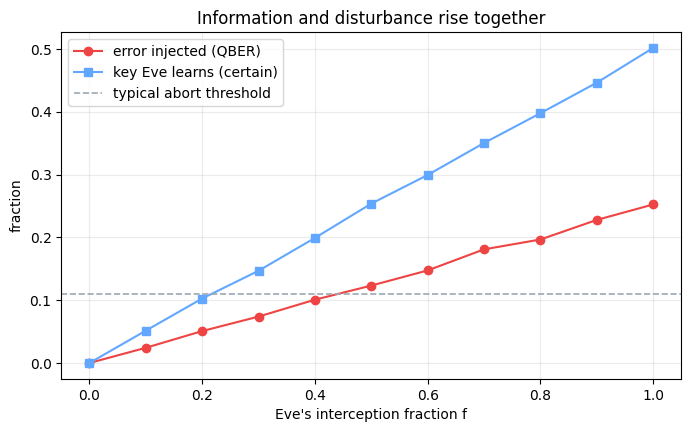

In [5]:
fractions = np.linspace(0, 1, 11)
qbers, eve_info = [], []
for f in fractions:
    run = simulate(40000, rng, eve_fraction=f)
    s = run["sift"]
    qbers.append(qber(run))
    eve_info.append(float(run["eve_known"][s].mean()))  # fraction of sifted key Eve knows for sure

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(fractions, qbers, marker="o", color="#ef4444", label="error injected (QBER)")
ax.plot(fractions, eve_info, marker="s", color="#62a7ff", label="key Eve learns (certain)")
ax.axhline(0.11, color="#9ba8b5", ls="--", lw=1.2, label="typical abort threshold")
ax.set_xlabel("Eve's interception fraction f")
ax.set_ylabel("fraction")
ax.set_title("Information and disturbance rise together")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


**Watch the errors accumulate.** Each frame is one sifted photon; the gauge tracks the running error rate as a full eavesdropper corrupts the key toward 25%.


In [6]:
def animate_channel(n=60, eve_fraction=1.0, seed=1):
    local = np.random.default_rng(seed)
    run = simulate(n, local, eve_fraction=eve_fraction)
    sift_idx = np.where(run["sift"])[0]
    errors = (run["a_bits"][sift_idx] != run["b_bits"][sift_idx]).astype(float)
    running = np.cumsum(errors) / (np.arange(len(errors)) + 1)

    fig, (axc, axg) = plt.subplots(1, 2, figsize=(11, 4.6))

    def angle(bit, basis):
        return {(0, RECT): 0, (1, RECT): 90, (0, DIAG): 45, (1, DIAG): 135}[(bit, basis)]

    def update(j):
        axc.clear(); axg.clear()
        i = sift_idx[j]
        eve_on = run["intercepted"][i]
        # channel
        axc.plot([0.08, 0.92], [0.5, 0.5], color="#42505f", lw=2, zorder=0)
        for x, name, col in [(0.08, "Alice", "#62a7ff"), (0.92, "Bob", "#9bd46a")]:
            axc.scatter([x], [0.5], s=900, color=col, zorder=2)
            axc.text(x, 0.5, name, ha="center", va="center", color="#0c1015", fontsize=9, fontweight="bold")
        if eve_fraction > 0:
            axc.scatter([0.5], [0.5], s=820, color="#ef6a7a" if eve_on else "#3a2530", zorder=2)
            axc.text(0.5, 0.5, "Eve", ha="center", va="center", color="#0c1015" if eve_on else "#9ba8b5",
                     fontsize=9, fontweight="bold")
        # photon polarization arrow
        th = np.deg2rad(angle(run["a_bits"][i], run["a_bases"][i]))
        dx, dy = 0.05 * np.cos(th), 0.12 * np.sin(th)
        axc.annotate("", xy=(0.3 + dx, 0.72 + dy), xytext=(0.3 - dx, 0.72 - dy),
                     arrowprops=dict(arrowstyle="<->", color="#f2b84b", lw=3))
        axc.text(0.5, 0.9, f"photon {j + 1}: Alice basis {BASIS[run['a_bases'][i]]}, bit {run['a_bits'][i]}"
                           + ("   |   Eve intercepted" if eve_on else ""),
                 ha="center", fontsize=9, color="#eef3f8")
        axc.set_xlim(0, 1); axc.set_ylim(0, 1); axc.axis("off")
        # gauge
        axg.plot(np.arange(1, j + 2), running[: j + 1], color="#ef4444", lw=2.5)
        axg.axhline(0.25, color="#9ba8b5", ls="--", lw=1.2, label="intercept-resend = 25%")
        axg.axhline(0.11, color="#22c55e", ls=":", lw=1.2, label="abort threshold")
        axg.set_xlim(0, len(errors)); axg.set_ylim(0, 0.5)
        axg.set_xlabel("sifted photons compared"); axg.set_ylabel("running error rate")
        axg.set_title(f"QBER so far: {running[j]:.2f}", fontsize=10)
        axg.legend(loc="upper right", fontsize=8); axg.grid(alpha=0.25)

    anim = animation.FuncAnimation(fig, update, frames=len(sift_idx), interval=320)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate_channel(n=60, eve_fraction=1.0, seed=1)


## 5. Catching the Eavesdropper

Alice and Bob never see Eve. They see only their sifted key. To check it, they **sacrifice a random sample** of those bits: they announce them publicly and count how many disagree. If the sampled error rate is near zero, the rest of the key is trustworthy. If it is anywhere near 25%, they **abort** and try again - the key is burned but never used.

This is the same move as a zero-knowledge proof's repeated challenges: spend a random sample to expose tampering you cannot see directly.


**Detection.** Estimate QBER from a small public sample and raise the alarm above a threshold.


In [7]:
def eavesdrop_alarm(true_qber, sample_size, rng, threshold=0.11, trials=20000):
    hits = 0
    for _ in range(trials):
        if (rng.random(sample_size) < true_qber).mean() > threshold:
            hits += 1
    return hits / trials


for label, qb in [("clean channel", 0.0), ("full eavesdropper", 0.25)]:
    p = eavesdrop_alarm(qb, 64, rng)
    print(f"{label:18s} (QBER {qb:.2f}): eavesdrop alarm fires {p:.1%} of the time")


clean channel      (QBER 0.00): eavesdrop alarm fires 0.0% of the time
full eavesdropper  (QBER 0.25): eavesdrop alarm fires 99.6% of the time


## 6. Failure Mode: When Copying Is Allowed

Why does any of this work? Because a photon's unknown polarization **cannot be cloned**. Strip that away - imagine Alice sent ordinary classical bits Eve can copy - and the whole guarantee collapses.

Below, Eve copies every intercepted bit perfectly and forwards the original untouched. She learns the entire key and injects **zero** error, so the sample check sees a clean channel and Alice and Bob proceed, fully compromised. No-cloning is not a detail of BB84; it is the only reason it is secure.


**Break it.** Let Eve copy classical bits with no disturbance and compare the error rate.


In [8]:
quantum_eve = simulate(20000, rng, eve_fraction=1.0)
classical_eve = simulate(20000, rng, eve_fraction=1.0, classical=True)

print(f"quantum photons,  full Eve: QBER {qber(quantum_eve):.4f}  -> caught")
print(f"classical bits,   full Eve: QBER {qber(classical_eve):.4f}  -> undetected, key fully leaked")


quantum photons,  full Eve: QBER 0.2497  -> caught
classical bits,   full Eve: QBER 0.0000  -> undetected, key fully leaked


## 7. Mini-Challenge

Try one:

1. Vary the abort threshold and the sample size. How large a sample makes a 25% eavesdropper essentially certain to be caught, and what is the chance of a false alarm on a clean channel?
2. Give Eve a smarter rule: always measure in the rectilinear basis. Does her QBER change from the random-basis 25%? Why?
3. Let Eve intercept only the first half of the photons. What sample placement would miss her, and what does that say about sampling *randomly*?
4. Add channel noise (flip a small fraction of Bob's bits even with no Eve). How does that blur the line between "noise" and "eavesdropper," and why do real systems set the abort threshold above zero?
5. From the tradeoff plot, estimate how much of the key Eve can learn while staying under an 11% abort threshold.


**Invariant check.** A clean matched-basis bit never disagrees, and full intercept-resend drives the sifted error rate to 1/4.


In [9]:
clean = simulate(50000, np.random.default_rng(11))
s = clean["sift"]
print("clean channel: every matched-basis bit agrees:", bool((clean['a_bits'][s] == clean['b_bits'][s]).all()))

full = simulate(200000, np.random.default_rng(12), eve_fraction=1.0)
print(f"full intercept-resend QBER -> 1/4: {qber(full):.4f}")


clean channel: every matched-basis bit agrees: True
full intercept-resend QBER -> 1/4: 0.2511


## Visual Trace + Rigor Studio

**Problem frame.** Share a secret key over a fully public channel such that any eavesdropper is detected, with security resting on physics rather than on a computational hardness assumption.

**Interactive animation target.** Animate the photon stream Alice -> (Eve) -> Bob: each photon's polarization arrow, the chosen bases, whether the bit is sifted, and a running QBER gauge that climbs toward 25% when a full eavesdropper is present.

**Correctness handle.** With matched bases and no eavesdropper, Bob's bit equals Alice's (zero error). Intercept-resend corrupts a sifted bit with probability `1/2 x 1/2 = 1/4`. No-cloning forbids copying an unknown state, so information gain forces disturbance.

**Complexity handle.** `n` raw photons yield about `n/2` sifted bits (bases agree half the time); a random sample of the sifted key is sacrificed to estimate QBER, and the usable key rate is linear in `n`.

**Failure mode to test.** Replace the quantum photons with classical, copyable bits. Eve clones the whole key, injects zero error, and passes the sample check undetected - so the security depends entirely on no-cloning.

**Studio task.** Play Eve: sweep the interception fraction and confirm the key she learns tracks the error she injects, then find the largest attack that stays under the abort threshold and how little key it leaks.

**Transfer.** Sacrificing a random sample to expose hidden tampering is the same idea as a zero-knowledge proof's repeated challenges; the measurement-disturbs-the-state mechanic is the superposition and collapse from Grover. Where Shor showed quantum computation *breaking* RSA's hardness, BB84 shows physics *restoring* security that no computer can strip away.


## Sources and Further Reading

- Charles H. Bennett and Gilles Brassard, [Quantum cryptography: Public key distribution and coin tossing](https://doi.org/10.1016/j.tcs.2014.05.025), 1984 (reprinted 2014) - the original BB84 protocol.
- Nicolas Gisin, Gregoire Ribordy, Wolfgang Tittel, and Hugo Zbinden, [Quantum cryptography](https://doi.org/10.1103/RevModPhys.74.145), *Reviews of Modern Physics* 74, 145 (2002) - a thorough survey.
- Michael A. Nielsen and Isaac L. Chuang, *Quantum Computation and Quantum Information* (2010), chapter 12 - the no-cloning theorem and quantum key distribution.

This is a transparent teaching simulation of polarization states and ideal detectors. Real systems also handle channel noise, photon-number-splitting attacks, error correction, and privacy amplification.
